<a href="https://colab.research.google.com/github/RekhaThota22/sentiment-analysis-lstm-nlp/blob/main/Amazon_Fine_Food_review_using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
### Understanding LSTM and RNN with an example
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from tensorflow.keras.preprocessing.text import Tokenizer

In [3]:
print("Amazon fine food review dataset")
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

Amazon fine food review dataset
Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [4]:
csv_file = os.path.join(path,"Reviews.csv")

In [5]:
df = pd.read_csv(csv_file)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
df['Text'][3]

'If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.'

In [7]:
df.shape

(568454, 10)

In [8]:
df.columns.to_list()

['Id',
 'ProductId',
 'UserId',
 'ProfileName',
 'HelpfulnessNumerator',
 'HelpfulnessDenominator',
 'Score',
 'Time',
 'Summary',
 'Text']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [10]:
df.isna().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [11]:
df.dropna(inplace=True)

In [12]:
df.isna().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [13]:
#Data Visualization

df_clean = df[['Text','Score']]
df_clean

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5
...,...,...
568449,Great for sesame chicken..this is a good if no...,5
568450,I'm disappointed with the flavor. The chocolat...,2
568451,"These stars are small, so you can give 10-15 o...",5
568452,These are the BEST treats for training and rew...,5


In [14]:
# Rating distribution
Score_counts = df['Score'].value_counts().sort_index()
print(Score_counts)

Score
1     52264
2     29743
3     42638
4     80654
5    363102
Name: count, dtype: int64


In [15]:
# Rating distribution
for score, count in Score_counts.items():
  percentage = (count/len(df_clean))*100
  print(f"{score} Stars : {percentage:.2f}%")

1 Stars : 9.19%
2 Stars : 5.23%
3 Stars : 7.50%
4 Stars : 14.19%
5 Stars : 63.88%


In [16]:
# Have a look at some sample texts
for score in[1,2,3,4,5]:
  sample_review = df_clean[df_clean['Score']== score]['Text'].iloc[0]
  print(f"\n{score}--- Star Reviews")
  print(f"{sample_review [:200]}")


1--- Star Reviews
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

2--- Star Reviews
If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor

3--- Star Reviews
This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't 

4--- Star Reviews
This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powd

5--- Star Reviews
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. T

In [17]:
df_clean['text_length'] = df_clean['Text'].str.len()
df_clean['word_count'] = df_clean['Text'].str.split().str.len()

/tmp/ipykernel_6487/1053056101.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['text_length'] = df_clean['Text'].str.len()
/tmp/ipykernel_6487/1053056101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['word_count'] = df_clean['Text'].str.split().str.len()


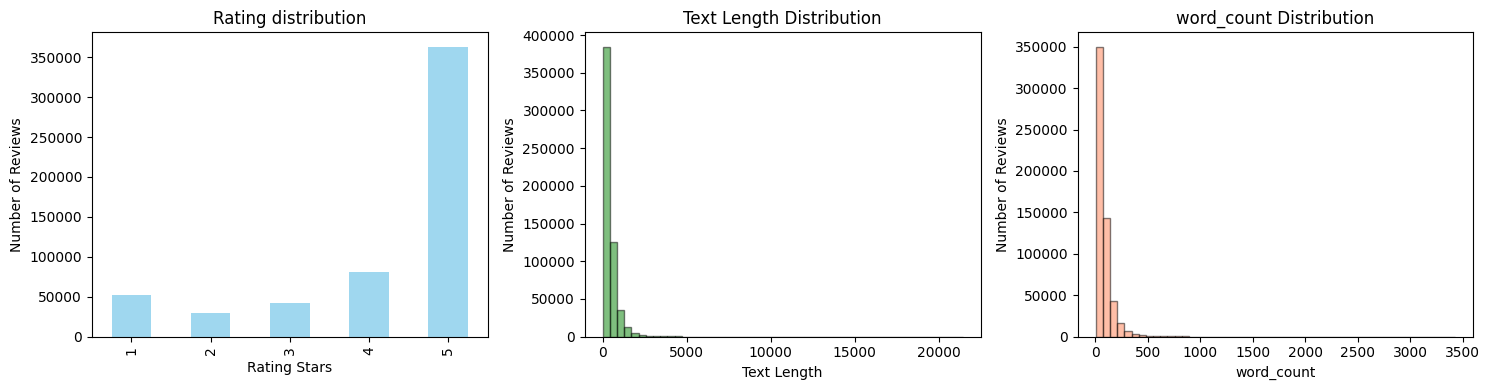

In [18]:
# Visualizing the data
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
Score_counts.plot(kind='bar', color ='skyblue',alpha = 0.8)
plt.title('Rating distribution')
plt.xlabel('Rating Stars')
plt.ylabel('Number of Reviews')

# text length distribution

plt.subplot(1,3,2)
plt.hist(df_clean['text_length'],bins = 50,alpha = 0.5,color = 'green',edgecolor = 'black')
plt.title('Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Number of Reviews')
plt.tight_layout()

# word_count_distribution
plt.subplot(1,3,3)
plt.hist(df_clean['word_count'],bins = 50,alpha = 0.5,color = 'coral',edgecolor = 'black')
plt.title('word_count Distribution')
plt.xlabel('word_count')
plt.ylabel('Number of Reviews')
plt.tight_layout()


In [19]:
df_clean.head()

,Text,Score,text_length,word_count
0,I have bought several of the Vitality canned d...,5,263,48
1,Product arrived labeled as Jumbo Salted Peanut...,1,190,31
2,This is a confection that has been around a fe...,4,509,94
3,If you are looking for the secret ingredient i...,2,219,41
4,Great taffy at a great price. There was a wid...,5,140,27


In [20]:
df_clean['Score'].value_counts()

,count
Score,
5,363102
4,80654
1,52264
3,42638
2,29743


In [21]:
# convert the data into binary
df_binary = df_clean[df_clean['Score'] !=3].copy()

#"I removed neutral reviews (rating 3) because they do not clearly represent
# positive or negative sentiment.
#Then I converted ratings into binary labels where ratings ≥4 are positive and ratings ≤2 are negative."

df_binary['sentiment'] = (df_binary['Score']>=4).astype(int)

In [22]:
print(f"Original Dataset : {len(df_clean)} reviews")
print(f"After removing 3 star rating : {len(df_binary)} reviews")

print("\n Class Distribution :")

print(f"Negative (1-2 stars :) {sum(df_binary['sentiment']==0)}")
print(f"Positive (4-5 stars :) { sum(df_binary['sentiment']==1)}")

# Checking if the data is imbalanced :

negative_pct = (sum(df_binary['sentiment']==0)/len(df_binary))*100
positive_pct = (sum(df_binary['sentiment']==1)/ len(df_binary))*100

print(f"\n class balance :")
print(f"Negative : {negative_pct} %")
print(f"Positive : {positive_pct} %")

if positive_pct or negative_pct > 70 :
  print(f"\n Dataset is heavily imbalance ---it is skewed ")


Original Dataset : 568401 reviews
After removing 3 star rating : 525763 reviews

 Class Distribution :
Negative (1-2 stars :) 82007
Positive (4-5 stars :) 443756

 class balance :
Negative : 15.597712277204748 %
Positive : 84.40228772279525 %

 Dataset is heavily imbalance ---it is skewed 


In [23]:
# Balancing the data either use the downSampling ir the up Sampling
from sklearn.utils import resample

negative_reviews = df_binary[df_binary['sentiment']==0]
positive_reviews = df_binary[df_binary['sentiment']==1]

print(f" Original Imbalance")
print(f" Negative : {len(negative_reviews)}, {len(negative_reviews)/len(df_binary)*100:.2f}")
print(f" Positive : {len(positive_reviews)},{len(positive_reviews)/len(df_binary)*100:.2f}")

 Original Imbalance
 Negative : 82007, 15.60
 Positive : 443756,84.40


In [24]:
# Under sampling strategy
n_minority = len(negative_reviews)
# I need to downsample the positive reviews

positive_downsample = resample(positive_reviews,
                             replace = False,
                             n_samples = n_minority,
                             random_state = 42)

df_balanced = pd.concat([negative_reviews,positive_downsample])

df_balanced

,Text,Score,text_length,word_count,sentiment
1,Product arrived labeled as Jumbo Salted Peanut...,1,190,31,0
3,If you are looking for the secret ingredient i...,2,219,41,0
12,My cats have been happily eating Felidae Plati...,1,399,79,0
16,I love eating them and they are good for watch...,2,195,42,0
26,"The candy is just red , No flavor . Just plan...",1,88,20,0
...,...,...,...,...,...
278890,"Fresh, rich and delicious Belgian chocolates. ...",5,90,14,1
92676,I have been on a quest for a number of years n...,5,1226,223,1
43586,These are my favorite flavored almonds! Inten...,5,128,21,1
434625,Great cereal but I couldn't find in the stores...,5,143,28,1


In [25]:
# Reshuffle coz the data is  downsampled using stratification we dont want the sequence as original data we dont want to bias the model
df.balanced = df_balanced.sample(frac = 1,random_state = 42).reset_index(drop = True)

/tmp/ipykernel_6487/128800680.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.balanced = df_balanced.sample(frac = 1,random_state = 42).reset_index(drop = True)


In [26]:
print(f"After balancing :")
print(f"Total sampling = {len(df_balanced)}")
print(f"Negative : {sum(df_balanced['sentiment']==0):,}, ({sum(df_balanced['sentiment']==0)/len(df_balanced)*100:.2f})")
print(f"Postive : {sum(df_balanced['sentiment']==1):,},({sum(df_balanced['sentiment']==1)/len(df_balanced)*100:.2f})")

After balancing :
Total sampling = 164014
Negative : 82,007, (50.00)
Postive : 82,007,(50.00)


 # Text Preprocessing:
 1) Convert to lower case
 2) Remove special chars(@,-,#,%)
 3) Keep only letters and spaces
 4)Remove any whitespaces

In [27]:
import re
def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z\s]','',text)
  text = ' '.join(text.split())
  return text

In [28]:
# Apply text processing
df_balanced['clean_text'] = df_balanced['Text'].apply(clean_text)

In [29]:
df_balanced.head(30)

,Text,Score,text_length,word_count,sentiment,clean_text
1,Product arrived labeled as Jumbo Salted Peanut...,1,190,31,0,product arrived labeled as jumbo salted peanut...
3,If you are looking for the secret ingredient i...,2,219,41,0,if you are looking for the secret ingredient i...
12,My cats have been happily eating Felidae Plati...,1,399,79,0,my cats have been happily eating felidae plati...
16,I love eating them and they are good for watch...,2,195,42,0,i love eating them and they are good for watch...
26,"The candy is just red , No flavor . Just plan...",1,88,20,0,the candy is just red no flavor just plan and ...
50,"This oatmeal is not good. Its mushy, soft, I d...",1,89,19,0,this oatmeal is not good its mushy soft i dont...
62,Arrived in 6 days and were so stale i could no...,1,71,17,0,arrived in days and were so stale i could not ...
67,"I purchased the Mango flavor, and to me it doe...",2,479,87,0,i purchased the mango flavor and to me it does...
73,Buyer Beware Please! This sweetener is not for...,1,1746,306,0,buyer beware please this sweetener is not for ...
74,It is okay. I would not go out of my way to b...,2,57,15,0,it is okay i would not go out of my way to buy...


In [30]:
for i in range(2):
  original =  df_balanced.iloc[i]['Text']
  cleaned = df_balanced.iloc[i]['clean_text']

  print(f"Original :{original}")
  print(f"Cleaned :{cleaned}")

Original :Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".
Cleaned :product arrived labeled as jumbo salted peanutsthe peanuts were actually small sized unsalted not sure if this was an error or if the vendor intended to represent the product as jumbo
Original :If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.
Cleaned :if you are looking for the secret ingredient in robitussin i believe i have found it i got this in addition to the root beer extract i ordered which was good and made some cherry soda the flavor is very medicinal


In [31]:
# Tokenization and Sequence Prep
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [129]:
Max_Features = 10000 # max words I will use from the vocabulary
Max_Length = 100 # You can change later but for now we will use it 100
# max_len is the length what you want to train on

X = df_balanced['clean_text'].values
Y = df_balanced['sentiment'].values

tokenizer  = Tokenizer(num_words = Max_Features,oov_token = '<OOV>')

tokenizer.fit_on_texts(X)
X_sequences = tokenizer.texts_to_sequences(X)
X_padded = pad_sequences(X_sequences,maxlen= Max_Length,padding = 'post',truncating = 'post')


In [33]:
print("=="*50)
print(f"Original Text : {X[0][:100]}\n ")
print("=="*50)
print(f"Sequenced text : {X_sequences[0]}\n")
print("=="*50)
print(f"Padded : {X_padded[0]}\n")
print("=="*50)

Original Text : product arrived labeled as jumbo salted peanutsthe peanuts were actually small sized unsalted not su
 
Sequenced text : [35, 338, 1659, 25, 5467, 2202, 1, 1029, 61, 230, 190, 1485, 3981, 15, 182, 36, 9, 16, 72, 2620, 37, 36, 2, 1227, 2099, 6, 6826, 2, 35, 25, 5467]

Padded : [  35  338 1659   25 5467 2202    1 1029   61  230  190 1485 3981   15
  182   36    9   16   72 2620   37   36    2 1227 2099    6 6826    2
   35   25 5467    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]



In [34]:
# Importing train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_padded,Y,
                                                 test_size = 0.2,
                                                 random_state = 42,
                                                 stratify = Y)

In [35]:
print(X_train.shape)
print(y_train.shape)

(131211, 100)
(131211,)


In [36]:
from tensorflow.keras.layers import Embedding,SimpleRNN,LSTM,Dense,Dropout
from tensorflow.keras.models import Sequential

In [37]:
def create_rnn_model():
  model = Sequential([
      Embedding(input_dim = Max_Features,output_dim = 12,input_length = Max_Length), #>100 really works well
      SimpleRNN(units=64,return_sequences=False),
      Dropout(0.5),
      Dense(32,activation = 'relu'),
      Dense(1,activation = 'sigmoid')
      ])
  return model

rnn_model = create_rnn_model()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [38]:
rnn_model.compile(optimizer= 'adam',
                  loss = 'binary_crossentropy',
                  metrics = ['accuracy'])

In [39]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Training RNN Model
rnn_history = rnn_model.fit(
    X_train,y_train,
    epochs = 5,
    batch_size = 128,
    validation_split = 0.2
)

Epoch 1/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.5146 - loss: 0.6953 - val_accuracy: 0.4972 - val_loss: 0.6950
Epoch 2/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5175 - loss: 0.6948 - val_accuracy: 0.6064 - val_loss: 0.6625
Epoch 3/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6348 - loss: 0.6504 - val_accuracy: 0.6659 - val_loss: 0.6293
Epoch 4/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6502 - loss: 0.6351 - val_accuracy: 0.5824 - val_loss: 0.6762
Epoch 5/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6279 - loss: 0.6502 - val_accuracy: 0.6006 - val_loss: 0.6677


In [41]:
final_training_accuracy = rnn_history.history['accuracy'][-1]
final_validation_accuracy = rnn_history.history['val_accuracy'][-1]
final_training_accuracy,final_validation_accuracy

(0.6279246807098389, 0.6005792021751404)

In [42]:
def create_lstm_model():
  model = Sequential([
      Embedding(input_dim = Max_Features, output_dim = 128,input_length = Max_Length),
      LSTM(units = 64,return_sequences = False),
      Dropout(0.5),
      Dense(32,activation = 'relu'),
      Dense(1,activation = 'sigmoid')
  ])
  return model

In [43]:
lstm_model = create_lstm_model()

In [44]:

lstm_model.compile(optimizer = 'adam',
                   loss = 'binary_crossentropy',
                   metrics = ['accuracy'])

In [45]:
# Training the lstm model
lstm_history = lstm_model.fit(
    X_train,y_train,
    epochs = 5,
    batch_size = 128,
    validation_split = 0.2)

Epoch 1/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6076 - loss: 0.6166 - val_accuracy: 0.8673 - val_loss: 0.3364
Epoch 2/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9017 - loss: 0.2553 - val_accuracy: 0.9122 - val_loss: 0.2207
Epoch 3/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9362 - loss: 0.1751 - val_accuracy: 0.9222 - val_loss: 0.2179
Epoch 4/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9537 - loss: 0.1327 - val_accuracy: 0.9241 - val_loss: 0.2099
Epoch 5/5
821/821 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9666 - loss: 0.0996 - val_accuracy: 0.9228 - val_loss: 0.2228


In [46]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,994,565 (15.24 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,663,044 (10.16 MB)

In [47]:
final_training_accuracy = lstm_history.history['accuracy'][-1]
final_validation_accuracy = lstm_history.history['val_accuracy'][-1]
final_training_accuracy,final_validation_accuracy

(0.9666184186935425, 0.9227984547615051)

In [48]:
# Hyper parameter tuning:
param_grid = {
    "model_type":['rnn','lstm'],
    'embedding_dim' :[64,128],
    'units' :[32,64,128],
    'dropout_rate':[0.3,0.5],
    'learning_rate':[0.001,0.01]
              }



print("Search space")
for param,values in param_grid.items():
  print(f"{param} : {values}")

  total_combinations = 1
  for values in param_grid.values():
    total_combinations *= len(values)
print(f"Total combinations : {total_combinations}")

Search space
model_type : ['rnn', 'lstm']
embedding_dim : [64, 128]
units : [32, 64, 128]
dropout_rate : [0.3, 0.5]
learning_rate : [0.001, 0.01]
Total combinations : 48


In [49]:
##OOP

def create_model_with_params(model_type = 'lstm',embedding_dim =12,units = 64,dropout_rate = 0.5,learning_rate = 0.01):
  model = Sequential([
      Embedding(Max_Features,embedding_dim,input_length = Max_Length)
  ])

  if model_type == 'lstm':
    model.add(LSTM(units ,return_sequences = False))
  else :
    model.add(SimpleRNN(units,return_sequences=False))

 # add remaining layers
  model.add(Dropout(dropout_rate))
  model.add(Dense(32,activation = 'relu'))
  model.add(Dense(1,activation = 'sigmoid'))
  model.compile(
     optimizer = 'adam',
     loss = 'binary_crossentropy',
     metrics = ['accuracy']
   )
  return model

In [133]:
# Random t rials to avoid time complexity---8/48
X_train = X_train[:30000]
y_train = y_train[:30000]

def random_trials(n_trials=8):
  results =[]
  np.random.seed(42)
  print(f"Testing {n_trials} random parameter combinations")

  for i in range(n_trials):
    params={
        'model_type': str(np.random.choice(param_grid['model_type'])),
        'embedding_dim' : int(np.random.choice(param_grid['embedding_dim'])),
        'units': int(np.random.choice(param_grid['units'])),
        'dropout_rate' : float(np.random.choice(param_grid['dropout_rate'])),
        'learning_rate' : float(np.random.choice(param_grid['learning_rate']))
    }
    print(f"\n---------Trial : {i+1}/{n_trials}----------")
    print(f"Parameters : {params}")

    try:

      model = create_model_with_params(**params)
      history = model.fit(X_train,y_train,batch_size = 128,
                          epochs = 5,
                          validation_split = 0.2
                          )
      val_accuracy = max(history.history['val_accuracy'])

      results.append({
    "trial": i+1,
    "params": params,
    "val_accuracy": val_accuracy,
    'model' : model

      })

      print(f"Validation Accuracy : {val_accuracy}")

    except Exception as e:
      print(f"Error in trials : {str(e)}")
      continue
  return results

In [134]:
search_results = random_trials(4)

Testing 4 random parameter combinations

---------Trial : 1/4----------
Parameters : {'model_type': 'rnn', 'embedding_dim': 128, 'units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001}
Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6021 - loss: 0.6604 - val_accuracy: 0.6883 - val_loss: 0.6092
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7207 - loss: 0.5735 - val_accuracy: 0.7017 - val_loss: 0.5875
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7672 - loss: 0.5116 - val_accuracy: 0.7063 - val_loss: 0.6024
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7847 - loss: 0.4816 - val_accuracy: 0.6973 - val_loss: 0.6245
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8210 - loss: 0.4225 - val_accuracy: 0.6805 - val_loss: 0.6299
Validation Accuracy : 0.706333339214325

---------Trial : 2/4----------
Parameters : {'model_type': 'lstm', 'embedding_dim': 64, 'units': 32, 'dropout_rate': 0.3, 'learning_

In [136]:
if search_results:
  best_result = max(search_results,key = lambda x: x['val_accuracy'])
best_result

{'trial': 2,
 'params': {'model_type': 'lstm',
  'embedding_dim': 64,
  'units': 32,
  'dropout_rate': 0.3,
  'learning_rate': 0.01},
 'val_accuracy': 0.7416666746139526,
 'model': <Sequential name=sequential_27, built=True>}

In [137]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.models import load_model
import pickle

In [138]:



if search_results:
  best_params = best_result['params']
  best_model = create_model_with_params(**best_params)
  callbacks = [
      ModelCheckpoint(
          'best_amazon_sentiment_model.h5',
          monitor ='val_accuracy',
          save_best_only = True,
          mode = 'max'
      ),
      EarlyStopping(
          monitor = 'val_loss',
          patience = 3,
          restore_best_weights = True
      )
  ]
  final_history = best_model.fit(
      X_train,y_train,
      epochs = 10,
      batch_size = 128,
      validation_split = 0.2,
      callbacks = callbacks
  )

  with open('amazon_sentiment_tokenizer.pkl','wb') as f:
    pickle.dump(tokenizer,f)

Epoch 1/10
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5269 - loss: 0.6890

188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5472 - loss: 0.6805 - val_accuracy: 0.5817 - val_loss: 0.6595
Epoch 2/10
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5864 - loss: 0.6482

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5872 - loss: 0.6407 - val_accuracy: 0.5945 - val_loss: 0.5979
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6597 - loss: 0.6077

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6235 - loss: 0.6163 - val_accuracy: 0.5988 - val_loss: 0.6231
Epoch 4/10
182/188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6278 - loss: 0.5707

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6351 - loss: 0.5793 - val_accuracy: 0.7103 - val_loss: 0.5624
Epoch 5/10
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8465 - loss: 0.3911

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8614 - loss: 0.3649 - val_accuracy: 0.8462 - val_loss: 0.3838
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8694 - loss: 0.3278 - val_accuracy: 0.8283 - val_loss: 0.4108
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9049 - loss: 0.2668

188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9119 - loss: 0.2485 - val_accuracy: 0.8632 - val_loss: 0.3631
Epoch 8/10
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9423 - loss: 0.1703

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9444 - loss: 0.1656 - val_accuracy: 0.8675 - val_loss: 0.3680
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9619 - loss: 0.1231 - val_accuracy: 0.8630 - val_loss: 0.4207
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9743 - loss: 0.0906 - val_accuracy: 0.8638 - val_loss: 0.5006


In [139]:
loaded_model = load_model('/content/best_amazon_sentiment_model.h5')
with open('amazon_sentiment_tokenizer.pkl','rb') as f:
  loaded_tokenizer=pickle.load(f)

In [140]:
print(padded)

NameError: name 'padded' is not defined

In [141]:
test_sentences =[
    "This product is amazing! I love it",
    "Terrible quality,waste of money",
    "great food,fast delivery,highly recommended"
]
def predict_sentiment(text):
  clean = clean_text(text)
  sequence = loaded_tokenizer.texts_to_sequences([clean])
  padded = pad_sequences(sequence,maxlen= Max_Length,padding = 'post')
  prob= loaded_model.predict(padded)[0][0]
  sentiment = 'Positive' if prob >0.5 else 'negative'
  return sentiment,prob

for i,sentence in enumerate(test_sentences):
    sentiment,probability = predict_sentiment(sentence)
    print(f"\nSentence : {i+1} :{sentence}")
    print(f"Prediction :{sentiment} (probability: {probability}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step

Sentence : 1 :This product is amazing! I love it
Prediction :Positive (probability: 0.95103919506073
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Sentence : 2 :Terrible quality,waste of money
Prediction :negative (probability: 0.012491093948483467
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Sentence : 3 :great food,fast delivery,highly recommended
Prediction :Positive (probability: 0.9121242761611938
